# Pass/Fail Prediction - Model Training and Evaluation

This notebook trains multiple models on the UCI dataset and evaluates them on the xAPI dataset for cross-validation.

## Workflow:
1. Load prepared datasets (UCI and xAPI)
2. Split UCI into train/validation sets
3. Train multiple classification models
4. Evaluate models on validation set (UCI)
5. Evaluate best model on test set (xAPI)
6. Compare model performance and select the best model


In [1]:
# Install required packages
!pip install -q pandas numpy scikit-learn matplotlib seaborn



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python3.11 -m pip install --upgrade pip


In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('ggplot')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Load Prepared Datasets


In [3]:
# Load prepared datasets
import os
import json

# Find prepared data directory
prepared_data_dir = 'prepared_data'
if not os.path.exists(prepared_data_dir):
    raise FileNotFoundError(f"Prepared data directory not found: {prepared_data_dir}. Please run data_preparation.ipynb first.")

# Load datasets
uci_path = os.path.join(prepared_data_dir, 'uci_pass_fail_prepared.csv')
xapi_path = os.path.join(prepared_data_dir, 'xapi_pass_fail_prepared.csv')
info_path = os.path.join(prepared_data_dir, 'feature_info.json')

df_uci = pd.read_csv(uci_path)
df_xapi = pd.read_csv(xapi_path)

# Load feature information
with open(info_path, 'r') as f:
    feature_info = json.load(f)

print(f"UCI dataset: {df_uci.shape[0]} samples × {df_uci.shape[1]} columns")
print(f"xAPI dataset: {df_xapi.shape[0]} samples × {df_xapi.shape[1]} columns")
print(f"\nFeature columns: {feature_info['feature_columns']}")
print(f"Target column: {feature_info['target_column']}")

# Display first few rows
print("\nUCI dataset (first 5 rows):")
print(df_uci.head())
print("\nxAPI dataset (first 5 rows):")
print(df_xapi.head())


UCI dataset: 1044 samples × 7 columns
xAPI dataset: 480 samples × 7 columns

Feature columns: ['gender_encoded', 'absences_normalized', 'engagement_normalized', 'parental_support', 'academic_level_normalized']
Target column: pass_fail

UCI dataset (first 5 rows):
   gender_encoded  absences_normalized  engagement_normalized  \
0               0             0.080000               0.499234   
1               0             0.053333               0.499234   
2               0             0.133333               0.499234   
3               0             0.026667               0.749617   
4               0             0.053333               0.499234   

   parental_support  academic_level_normalized  pass_fail pass_fail_label  
0                 0                        0.0          0            Fail  
1                 1                        0.0          0            Fail  
2                 0                        0.3          1            Pass  
3                 1                      

## 2. Prepare Data for Training


In [4]:
# Extract features and target
feature_columns = feature_info['feature_columns']
target_column = feature_info['target_column']

# UCI dataset: Split into train and validation
X_uci = df_uci[feature_columns]
y_uci = df_uci[target_column]

# Split UCI: 80% train, 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_uci, y_uci, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_uci  # Maintain class distribution
)

# xAPI dataset: Use as test set
X_test = df_xapi[feature_columns]
y_test = df_xapi[target_column]

print(f"Training set (UCI): {X_train.shape[0]} samples")
print(f"Validation set (UCI): {X_val.shape[0]} samples")
print(f"Test set (xAPI): {X_test.shape[0]} samples")

print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"Pass rate: {y_train.mean():.2%}")

print(f"\nValidation set class distribution:")
print(y_val.value_counts())
print(f"Pass rate: {y_val.mean():.2%}")

print(f"\nTest set class distribution:")
print(y_test.value_counts())
print(f"Pass rate: {y_test.mean():.2%}")


Training set (UCI): 835 samples
Validation set (UCI): 209 samples
Test set (xAPI): 480 samples

Training set class distribution:
pass_fail
1    651
0    184
Name: count, dtype: int64
Pass rate: 77.96%

Validation set class distribution:
pass_fail
1    163
0     46
Name: count, dtype: int64
Pass rate: 77.99%

Test set class distribution:
pass_fail
1    353
0    127
Name: count, dtype: int64
Pass rate: 73.54%


## 3. Initialize Models


In [5]:
# Initialize multiple models for comparison
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB()
}

print("Models initialized:")
for name in models.keys():
    print(f"  - {name}")


Models initialized:
  - Logistic Regression
  - Random Forest
  - Gradient Boosting
  - SVM
  - K-Nearest Neighbors
  - Naive Bayes


## 4. Train and Evaluate Models on Validation Set


In [6]:
# Train models and evaluate on validation set
results = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training {name}...")
    print('='*60)
    
    # Train model
    model.fit(X_train, y_train)
    
    # Predictions on validation set
    y_val_pred = model.predict(X_val)
    y_val_pred_proba = model.predict_proba(X_val)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred)
    recall = recall_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)
    
    # ROC AUC (if probabilities available)
    roc_auc = roc_auc_score(y_val, y_val_pred_proba) if y_val_pred_proba is not None else None
    
    # Store results
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'y_val_pred': y_val_pred,
        'y_val_pred_proba': y_val_pred_proba
    }
    
    # Print results
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    if roc_auc is not None:
        print(f"ROC AUC:   {roc_auc:.4f}")
    
    # Confusion matrix
    cm = confusion_matrix(y_val, y_val_pred)
    print(f"\nConfusion Matrix:")
    print(cm)



Training Logistic Regression...
Accuracy:  0.7799
Precision: 0.7854
Recall:    0.9877
F1 Score:  0.8750
ROC AUC:   0.6662

Confusion Matrix:
[[  2  44]
 [  2 161]]

Training Random Forest...
Accuracy:  0.7990
Precision: 0.8235
Recall:    0.9448
F1 Score:  0.8800
ROC AUC:   0.6686

Confusion Matrix:
[[ 13  33]
 [  9 154]]

Training Gradient Boosting...
Accuracy:  0.7943
Precision: 0.8191
Recall:    0.9448
F1 Score:  0.8775
ROC AUC:   0.6236

Confusion Matrix:
[[ 12  34]
 [  9 154]]

Training SVM...
Accuracy:  0.7990
Precision: 0.8010
Recall:    0.9877
F1 Score:  0.8846
ROC AUC:   0.6860

Confusion Matrix:
[[  6  40]
 [  2 161]]

Training K-Nearest Neighbors...
Accuracy:  0.7799
Precision: 0.8128
Recall:    0.9325
F1 Score:  0.8686
ROC AUC:   0.6374

Confusion Matrix:
[[ 11  35]
 [ 11 152]]

Training Naive Bayes...
Accuracy:  0.8086
Precision: 0.8254
Recall:    0.9571
F1 Score:  0.8864
ROC AUC:   0.6438

Confusion Matrix:
[[ 13  33]
 [  7 156]]


## 5. Compare Model Performance


Model Performance Comparison (Validation Set):
              Model  Accuracy  Precision   Recall  F1 Score  ROC AUC
        Naive Bayes  0.808612   0.825397 0.957055  0.886364 0.643838
                SVM  0.799043   0.800995 0.987730  0.884615 0.685983
      Random Forest  0.799043   0.823529 0.944785  0.880000 0.668578
  Gradient Boosting  0.794258   0.819149 0.944785  0.877493 0.623566
Logistic Regression  0.779904   0.785366 0.987730  0.875000 0.666244
K-Nearest Neighbors  0.779904   0.812834 0.932515  0.868571 0.637437


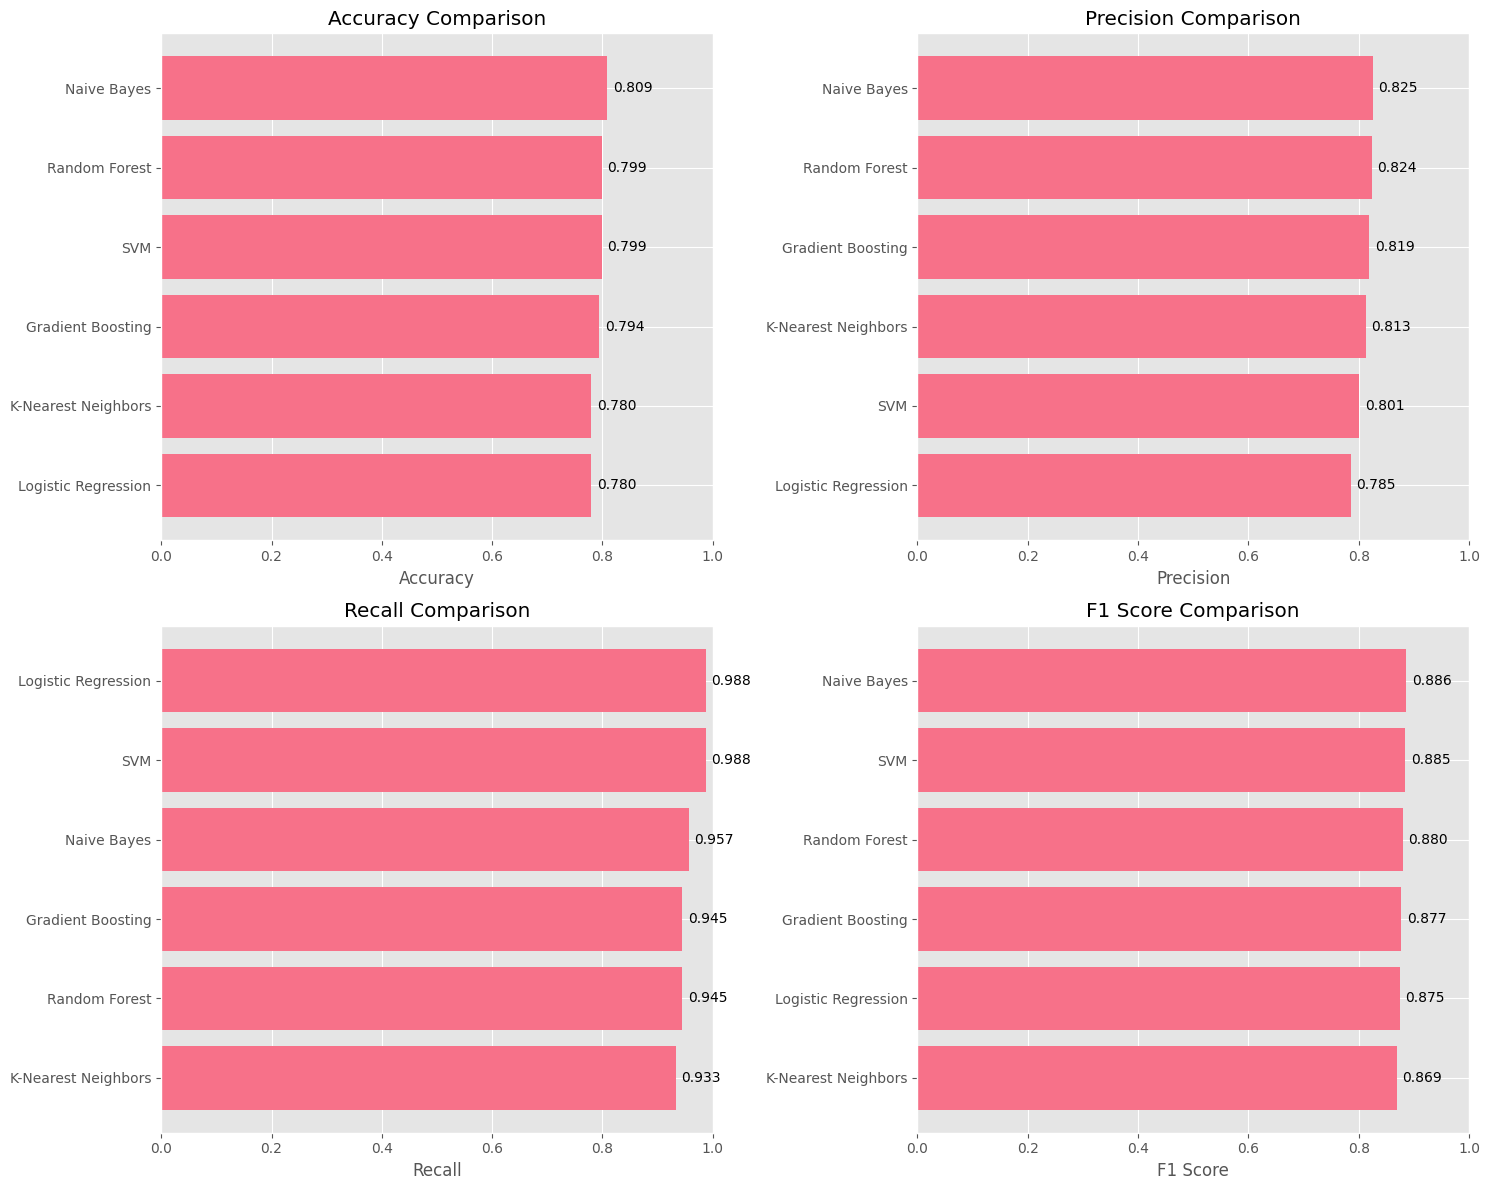

In [7]:
# Create comparison dataframe
comparison_data = []
for name, result in results.items():
    comparison_data.append({
        'Model': name,
        'Accuracy': result['accuracy'],
        'Precision': result['precision'],
        'Recall': result['recall'],
        'F1 Score': result['f1'],
        'ROC AUC': result['roc_auc'] if result['roc_auc'] is not None else np.nan
    })

df_comparison = pd.DataFrame(comparison_data)
df_comparison = df_comparison.sort_values('F1 Score', ascending=False)

print("Model Performance Comparison (Validation Set):")
print("="*60)
print(df_comparison.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    df_comparison_sorted = df_comparison.sort_values(metric, ascending=True)
    ax.barh(df_comparison_sorted['Model'], df_comparison_sorted[metric])
    ax.set_xlabel(metric)
    ax.set_title(f'{metric} Comparison')
    ax.set_xlim(0, 1)
    for i, v in enumerate(df_comparison_sorted[metric]):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()


## 6. Select Best Model


In [8]:
# Select best model based on F1 score (balanced metric)
best_model_name = df_comparison.iloc[0]['Model']
best_model = results[best_model_name]['model']

print(f"Best Model: {best_model_name}")
print(f"Validation F1 Score: {results[best_model_name]['f1']:.4f}")
print(f"Validation Accuracy: {results[best_model_name]['accuracy']:.4f}")
roc_auc_val = results[best_model_name]['roc_auc']
if roc_auc_val is not None:
    print(f"Validation ROC AUC: {roc_auc_val:.4f}")
else:
    print(f"Validation ROC AUC: N/A")


Best Model: Naive Bayes
Validation F1 Score: 0.8864
Validation Accuracy: 0.8086
Validation ROC AUC: 0.6438


## 7. Evaluate Best Model on Test Set (xAPI)


In [9]:
# Evaluate best model on test set (xAPI)
print(f"\n{'='*60}")
print(f"Evaluating {best_model_name} on Test Set (xAPI)")
print('='*60)

# Predictions on test set
y_test_pred = best_model.predict(X_test)
y_test_pred_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, 'predict_proba') else None

# Calculate metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_pred_proba) if y_test_pred_proba is not None else None

print(f"\nTest Set Performance:")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1 Score:  {test_f1:.4f}")
if test_roc_auc is not None:
    print(f"ROC AUC:   {test_roc_auc:.4f}")

# Confusion matrix
test_cm = confusion_matrix(y_test, y_test_pred)
print(f"\nConfusion Matrix (Test Set):")
print(test_cm)

# Classification report
print(f"\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=['Fail', 'Pass']))



Evaluating Naive Bayes on Test Set (xAPI)

Test Set Performance:
Accuracy:  0.3521
Precision: 0.6479
Recall:    0.2606
F1 Score:  0.3717
ROC AUC:   0.5053

Confusion Matrix (Test Set):
[[ 77  50]
 [261  92]]

Classification Report (Test Set):
              precision    recall  f1-score   support

        Fail       0.23      0.61      0.33       127
        Pass       0.65      0.26      0.37       353

    accuracy                           0.35       480
   macro avg       0.44      0.43      0.35       480
weighted avg       0.54      0.35      0.36       480



## 8. Visualize Results


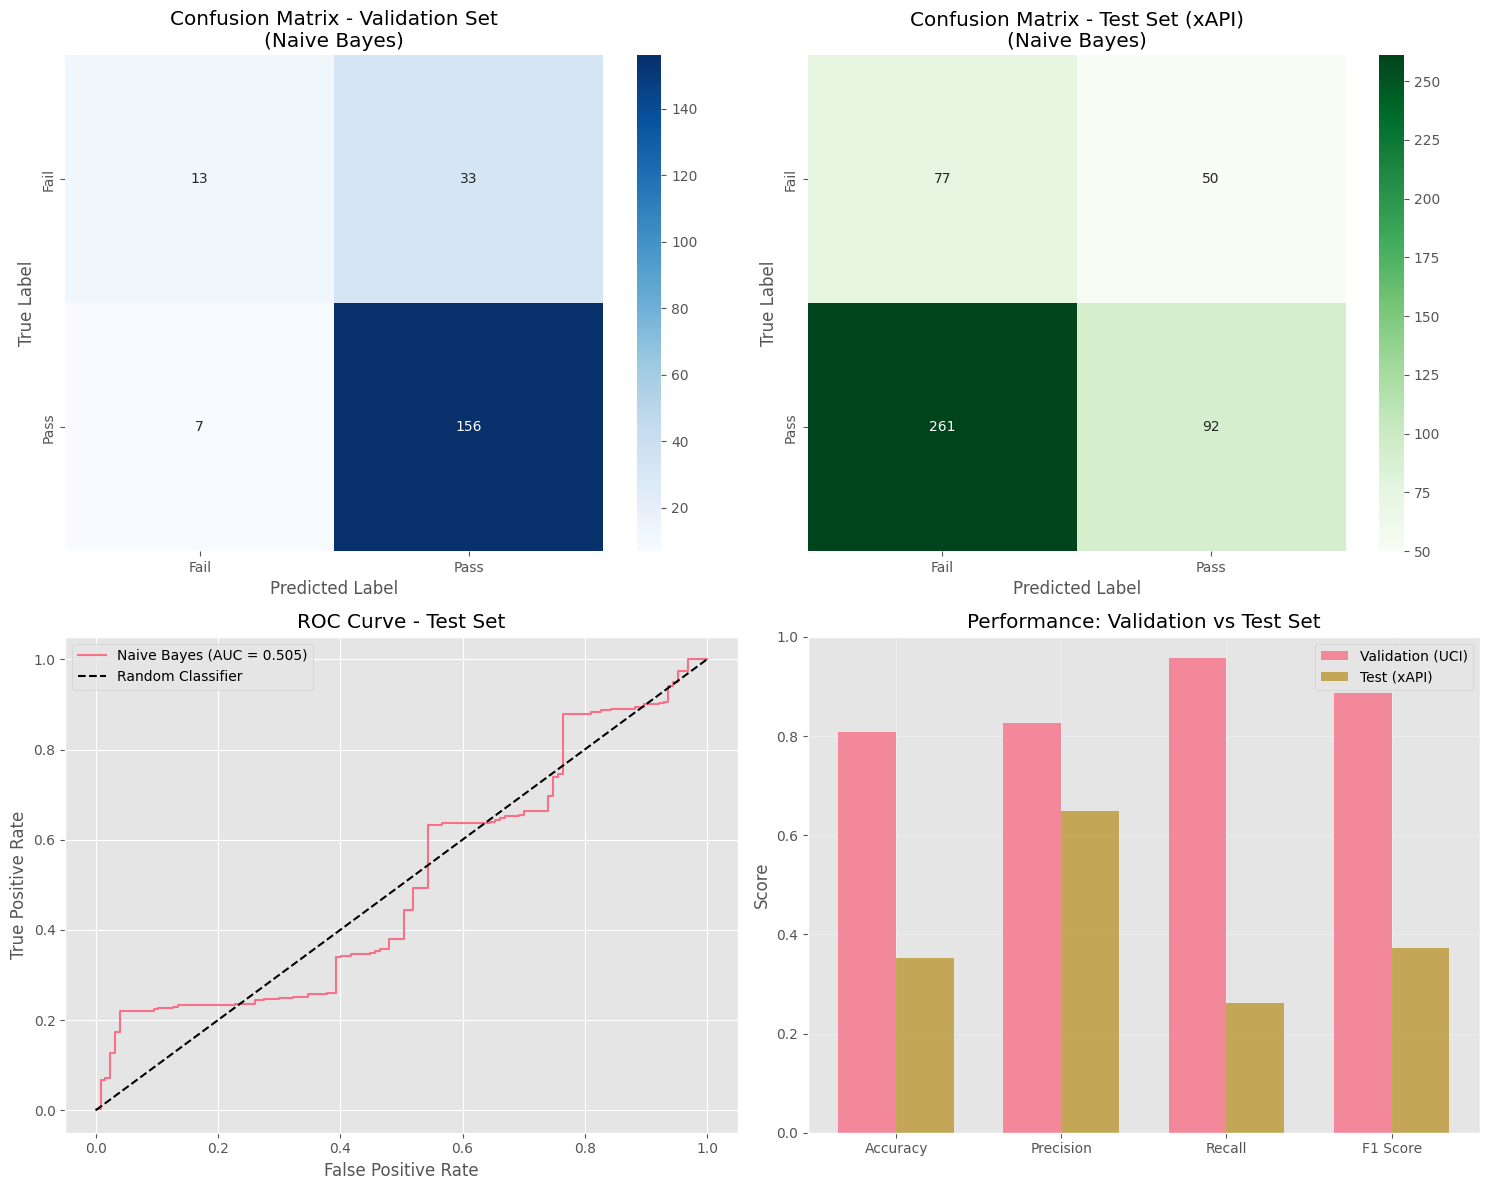

In [10]:
# Create visualization of results
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Confusion Matrix (Validation Set)
ax1 = axes[0, 0]
sns.heatmap(confusion_matrix(y_val, results[best_model_name]['y_val_pred']), 
            annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
ax1.set_title(f'Confusion Matrix - Validation Set\n({best_model_name})')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')

# 2. Confusion Matrix (Test Set)
ax2 = axes[0, 1]
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Greens', ax=ax2,
            xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
ax2.set_title(f'Confusion Matrix - Test Set (xAPI)\n({best_model_name})')
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')

# 3. ROC Curve (if probabilities available)
if y_test_pred_proba is not None:
    ax3 = axes[1, 0]
    fpr, tpr, _ = roc_curve(y_test, y_test_pred_proba)
    ax3.plot(fpr, tpr, label=f'{best_model_name} (AUC = {test_roc_auc:.3f})')
    ax3.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    ax3.set_xlabel('False Positive Rate')
    ax3.set_ylabel('True Positive Rate')
    ax3.set_title('ROC Curve - Test Set')
    ax3.legend()
    ax3.grid(True)

# 4. Performance Comparison: Validation vs Test
ax4 = axes[1, 1]
metrics_compare = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
val_scores = [
    results[best_model_name]['accuracy'],
    results[best_model_name]['precision'],
    results[best_model_name]['recall'],
    results[best_model_name]['f1']
]
test_scores = [test_accuracy, test_precision, test_recall, test_f1]

x = np.arange(len(metrics_compare))
width = 0.35
ax4.bar(x - width/2, val_scores, width, label='Validation (UCI)', alpha=0.8)
ax4.bar(x + width/2, test_scores, width, label='Test (xAPI)', alpha=0.8)
ax4.set_ylabel('Score')
ax4.set_title('Performance: Validation vs Test Set')
ax4.set_xticks(x)
ax4.set_xticklabels(metrics_compare)
ax4.legend()
ax4.set_ylim(0, 1)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Save Results and Model


In [11]:
# Create output directory
output_dir = 'models'
os.makedirs(output_dir, exist_ok=True)

# Save model comparison results
comparison_output_path = os.path.join(output_dir, 'model_comparison.csv')
df_comparison.to_csv(comparison_output_path, index=False)
print(f"Model comparison saved: {os.path.abspath(comparison_output_path)}")

# Save best model
import pickle
model_output_path = os.path.join(output_dir, 'best_model.pkl')
with open(model_output_path, 'wb') as f:
    pickle.dump(best_model, f)
print(f"Best model saved: {os.path.abspath(model_output_path)}")

# Save detailed results
results_summary = {
    'best_model': best_model_name,
    'validation_performance': {
        'accuracy': float(results[best_model_name]['accuracy']),
        'precision': float(results[best_model_name]['precision']),
        'recall': float(results[best_model_name]['recall']),
        'f1': float(results[best_model_name]['f1']),
        'roc_auc': float(results[best_model_name]['roc_auc']) if results[best_model_name]['roc_auc'] is not None else None
    },
    'test_performance': {
        'accuracy': float(test_accuracy),
        'precision': float(test_precision),
        'recall': float(test_recall),
        'f1': float(test_f1),
        'roc_auc': float(test_roc_auc) if test_roc_auc is not None else None
    },
    'feature_columns': feature_columns,
    'train_samples': len(X_train),
    'val_samples': len(X_val),
    'test_samples': len(X_test)
}

results_output_path = os.path.join(output_dir, 'results_summary.json')
with open(results_output_path, 'w') as f:
    json.dump(results_summary, f, indent=2)
print(f"Results summary saved: {os.path.abspath(results_output_path)}")


Model comparison saved: /Users/charaka/Desktop/Projects/uom-student-performance-analytics/pretests/charaka/analysis/pass-fail-prediction/models/model_comparison.csv
Best model saved: /Users/charaka/Desktop/Projects/uom-student-performance-analytics/pretests/charaka/analysis/pass-fail-prediction/models/best_model.pkl
Results summary saved: /Users/charaka/Desktop/Projects/uom-student-performance-analytics/pretests/charaka/analysis/pass-fail-prediction/models/results_summary.json


## 10. Summary


In [12]:
print("="*60)
print("FINAL SUMMARY")
print("="*60)

print(f"\nBest Model: {best_model_name}")
print(f"\nValidation Set Performance (UCI):")
print(f"  Accuracy:  {results[best_model_name]['accuracy']:.4f}")
print(f"  Precision: {results[best_model_name]['precision']:.4f}")
print(f"  Recall:    {results[best_model_name]['recall']:.4f}")
print(f"  F1 Score:  {results[best_model_name]['f1']:.4f}")
if results[best_model_name]['roc_auc'] is not None:
    print(f"  ROC AUC:   {results[best_model_name]['roc_auc']:.4f}")

print(f"\nTest Set Performance (xAPI - Cross-Dataset):")
print(f"  Accuracy:  {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  F1 Score:  {test_f1:.4f}")
if test_roc_auc is not None:
    print(f"  ROC AUC:   {test_roc_auc:.4f}")

print(f"\nPerformance Change (Validation → Test):")
print(f"  Accuracy:  {test_accuracy - results[best_model_name]['accuracy']:+.4f}")
print(f"  Precision: {test_precision - results[best_model_name]['precision']:+.4f}")
print(f"  Recall:    {test_recall - results[best_model_name]['recall']:+.4f}")
print(f"  F1 Score:  {test_f1 - results[best_model_name]['f1']:+.4f}")

print("\n" + "="*60)
print("Model training and evaluation completed!")
print("="*60)


FINAL SUMMARY

Best Model: Naive Bayes

Validation Set Performance (UCI):
  Accuracy:  0.8086
  Precision: 0.8254
  Recall:    0.9571
  F1 Score:  0.8864
  ROC AUC:   0.6438

Test Set Performance (xAPI - Cross-Dataset):
  Accuracy:  0.3521
  Precision: 0.6479
  Recall:    0.2606
  F1 Score:  0.3717
  ROC AUC:   0.5053

Performance Change (Validation → Test):
  Accuracy:  -0.4565
  Precision: -0.1775
  Recall:    -0.6964
  F1 Score:  -0.5146

Model training and evaluation completed!


## 11. Reverse Cross-Validation: Train on xAPI, Test on UCI

This section performs the reverse experiment: training models on xAPI dataset and evaluating on UCI dataset to test cross-dataset generalization in the opposite direction.


### 11.1 Prepare Data for Reverse Training


In [13]:
# Reverse setup: xAPI for training, UCI for testing
# xAPI dataset: Split into train and validation
X_xapi = df_xapi[feature_columns]
y_xapi = df_xapi[target_column]

# Split xAPI: 80% train, 20% validation
X_train_rev, X_val_rev, y_train_rev, y_val_rev = train_test_split(
    X_xapi, y_xapi, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_xapi  # Maintain class distribution
)

# UCI dataset: Use as test set
X_test_rev = df_uci[feature_columns]
y_test_rev = df_uci[target_column]

print(f"Training set (xAPI): {X_train_rev.shape[0]} samples")
print(f"Validation set (xAPI): {X_val_rev.shape[0]} samples")
print(f"Test set (UCI): {X_test_rev.shape[0]} samples")

print(f"\nTraining set class distribution:")
print(y_train_rev.value_counts())
print(f"Pass rate: {y_train_rev.mean():.2%}")

print(f"\nValidation set class distribution:")
print(y_val_rev.value_counts())
print(f"Pass rate: {y_val_rev.mean():.2%}")

print(f"\nTest set class distribution:")
print(y_test_rev.value_counts())
print(f"Pass rate: {y_test_rev.mean():.2%}")


Training set (xAPI): 384 samples
Validation set (xAPI): 96 samples
Test set (UCI): 1044 samples

Training set class distribution:
pass_fail
1    282
0    102
Name: count, dtype: int64
Pass rate: 73.44%

Validation set class distribution:
pass_fail
1    71
0    25
Name: count, dtype: int64
Pass rate: 73.96%

Test set class distribution:
pass_fail
1    814
0    230
Name: count, dtype: int64
Pass rate: 77.97%


### 11.2 Train and Evaluate Models on xAPI Validation Set


In [14]:
# Train models and evaluate on xAPI validation set
results_rev = {}

# Initialize models again for reverse training
models_rev = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB()
}

for name, model in models_rev.items():
    print(f"\n{'='*60}")
    print(f"Training {name} on xAPI...")
    print('='*60)
    
    # Train model
    model.fit(X_train_rev, y_train_rev)
    
    # Predictions on validation set
    y_val_rev_pred = model.predict(X_val_rev)
    y_val_rev_pred_proba = model.predict_proba(X_val_rev)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_val_rev, y_val_rev_pred)
    precision = precision_score(y_val_rev, y_val_rev_pred)
    recall = recall_score(y_val_rev, y_val_rev_pred)
    f1 = f1_score(y_val_rev, y_val_rev_pred)
    
    # ROC AUC (if probabilities available)
    roc_auc = roc_auc_score(y_val_rev, y_val_rev_pred_proba) if y_val_rev_pred_proba is not None else None
    
    # Store results
    results_rev[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'y_val_pred': y_val_rev_pred,
        'y_val_pred_proba': y_val_rev_pred_proba
    }
    
    # Print results
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    if roc_auc is not None:
        print(f"ROC AUC:   {roc_auc:.4f}")
    
    # Confusion matrix
    cm = confusion_matrix(y_val_rev, y_val_rev_pred)
    print(f"\nConfusion Matrix:")
    print(cm)



Training Logistic Regression on xAPI...
Accuracy:  0.8646
Precision: 0.8537
Recall:    0.9859
F1 Score:  0.9150
ROC AUC:   0.9206

Confusion Matrix:
[[13 12]
 [ 1 70]]

Training Random Forest on xAPI...
Accuracy:  0.9271
Precision: 0.9324
Recall:    0.9718
F1 Score:  0.9517
ROC AUC:   0.9893

Confusion Matrix:
[[20  5]
 [ 2 69]]

Training Gradient Boosting on xAPI...
Accuracy:  0.9688
Precision: 0.9595
Recall:    1.0000
F1 Score:  0.9793
ROC AUC:   0.9910

Confusion Matrix:
[[22  3]
 [ 0 71]]

Training SVM on xAPI...
Accuracy:  0.8333
Precision: 0.8571
Recall:    0.9296
F1 Score:  0.8919
ROC AUC:   0.9561

Confusion Matrix:
[[14 11]
 [ 5 66]]

Training K-Nearest Neighbors on xAPI...
Accuracy:  0.9479
Precision: 0.9342
Recall:    1.0000
F1 Score:  0.9660
ROC AUC:   0.9397

Confusion Matrix:
[[20  5]
 [ 0 71]]

Training Naive Bayes on xAPI...
Accuracy:  0.9479
Precision: 0.9714
Recall:    0.9577
F1 Score:  0.9645
ROC AUC:   0.9870

Confusion Matrix:
[[23  2]
 [ 3 68]]


In [15]:
# Create comparison dataframe for reverse training
comparison_data_rev = []
for name, result in results_rev.items():
    comparison_data_rev.append({
        'Model': name,
        'Accuracy': result['accuracy'],
        'Precision': result['precision'],
        'Recall': result['recall'],
        'F1 Score': result['f1'],
        'ROC AUC': result['roc_auc'] if result['roc_auc'] is not None else np.nan
    })

df_comparison_rev = pd.DataFrame(comparison_data_rev)
df_comparison_rev = df_comparison_rev.sort_values('F1 Score', ascending=False)

print("Model Performance Comparison (xAPI Validation Set):")
print("="*60)
print(df_comparison_rev.to_string(index=False))

# Select best model
best_model_name_rev = df_comparison_rev.iloc[0]['Model']
best_model_rev = results_rev[best_model_name_rev]['model']

print(f"\nBest Model (xAPI): {best_model_name_rev}")
print(f"Validation F1 Score: {results_rev[best_model_name_rev]['f1']:.4f}")
print(f"Validation Accuracy: {results_rev[best_model_name_rev]['accuracy']:.4f}")
roc_auc_val_rev = results_rev[best_model_name_rev]['roc_auc']
if roc_auc_val_rev is not None:
    print(f"Validation ROC AUC: {roc_auc_val_rev:.4f}")
else:
    print(f"Validation ROC AUC: N/A")


Model Performance Comparison (xAPI Validation Set):
              Model  Accuracy  Precision   Recall  F1 Score  ROC AUC
  Gradient Boosting  0.968750   0.959459 1.000000  0.979310 0.990986
K-Nearest Neighbors  0.947917   0.934211 1.000000  0.965986 0.939718
        Naive Bayes  0.947917   0.971429 0.957746  0.964539 0.987042
      Random Forest  0.927083   0.932432 0.971831  0.951724 0.989296
Logistic Regression  0.864583   0.853659 0.985915  0.915033 0.920563
                SVM  0.833333   0.857143 0.929577  0.891892 0.956056

Best Model (xAPI): Gradient Boosting
Validation F1 Score: 0.9793
Validation Accuracy: 0.9688
Validation ROC AUC: 0.9910


### 11.4 Evaluate Best Model on UCI Test Set


In [16]:
# Evaluate best model on UCI test set
print(f"\n{'='*60}")
print(f"Evaluating {best_model_name_rev} on Test Set (UCI)")
print('='*60)

# Predictions on test set
y_test_rev_pred = best_model_rev.predict(X_test_rev)
y_test_rev_pred_proba = best_model_rev.predict_proba(X_test_rev)[:, 1] if hasattr(best_model_rev, 'predict_proba') else None

# Calculate metrics
test_accuracy_rev = accuracy_score(y_test_rev, y_test_rev_pred)
test_precision_rev = precision_score(y_test_rev, y_test_rev_pred)
test_recall_rev = recall_score(y_test_rev, y_test_rev_pred)
test_f1_rev = f1_score(y_test_rev, y_test_rev_pred)
test_roc_auc_rev = roc_auc_score(y_test_rev, y_test_rev_pred_proba) if y_test_rev_pred_proba is not None else None

print(f"\nTest Set Performance (UCI):")
print(f"Accuracy:  {test_accuracy_rev:.4f}")
print(f"Precision: {test_precision_rev:.4f}")
print(f"Recall:    {test_recall_rev:.4f}")
print(f"F1 Score:  {test_f1_rev:.4f}")
if test_roc_auc_rev is not None:
    print(f"ROC AUC:   {test_roc_auc_rev:.4f}")

# Confusion matrix
test_cm_rev = confusion_matrix(y_test_rev, y_test_rev_pred)
print(f"\nConfusion Matrix (Test Set):")
print(test_cm_rev)

# Classification report
print(f"\nClassification Report (Test Set):")
print(classification_report(y_test_rev, y_test_rev_pred, target_names=['Fail', 'Pass']))



Evaluating Gradient Boosting on Test Set (UCI)

Test Set Performance (UCI):
Accuracy:  0.7797
Precision: 0.7797
Recall:    1.0000
F1 Score:  0.8762
ROC AUC:   0.5188

Confusion Matrix (Test Set):
[[  0 230]
 [  0 814]]

Classification Report (Test Set):
              precision    recall  f1-score   support

        Fail       0.00      0.00      0.00       230
        Pass       0.78      1.00      0.88       814

    accuracy                           0.78      1044
   macro avg       0.39      0.50      0.44      1044
weighted avg       0.61      0.78      0.68      1044



### 11.5 Compare Both Directions


CROSS-DATASET VALIDATION COMPARISON

Direction 1: Train on UCI → Test on xAPI
  Best Model: Naive Bayes
  Validation (UCI): F1 = 0.8864, Accuracy = 0.8086
  Test (xAPI): F1 = 0.3717, Accuracy = 0.3521
  Performance Change: F1 = -0.5146, Accuracy = -0.4565

Direction 2: Train on xAPI → Test on UCI
  Best Model: Gradient Boosting
  Validation (xAPI): F1 = 0.9793, Accuracy = 0.9688
  Test (UCI): F1 = 0.8762, Accuracy = 0.7797
  Performance Change: F1 = -0.1031, Accuracy = -0.1891


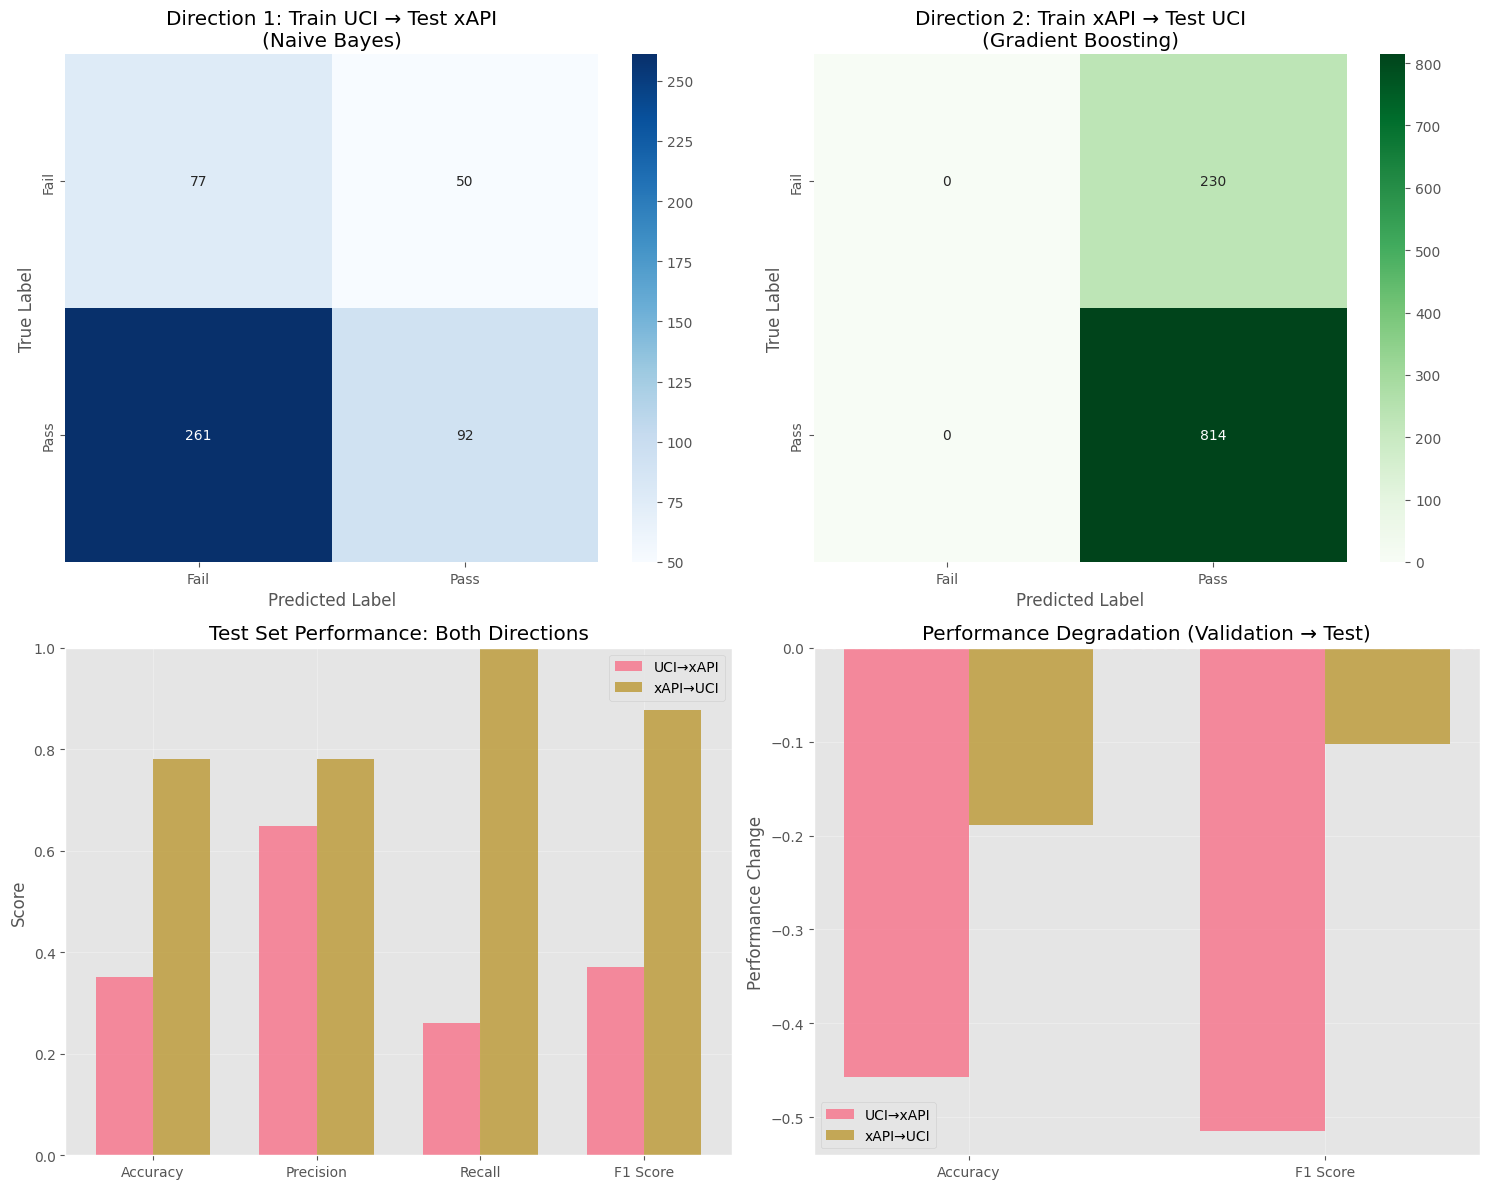

In [17]:
# Create comparison of both directions
print("="*60)
print("CROSS-DATASET VALIDATION COMPARISON")
print("="*60)

print("\nDirection 1: Train on UCI → Test on xAPI")
print(f"  Best Model: {best_model_name}")
print(f"  Validation (UCI): F1 = {results[best_model_name]['f1']:.4f}, Accuracy = {results[best_model_name]['accuracy']:.4f}")
print(f"  Test (xAPI): F1 = {test_f1:.4f}, Accuracy = {test_accuracy:.4f}")
print(f"  Performance Change: F1 = {test_f1 - results[best_model_name]['f1']:+.4f}, Accuracy = {test_accuracy - results[best_model_name]['accuracy']:+.4f}")

print("\nDirection 2: Train on xAPI → Test on UCI")
print(f"  Best Model: {best_model_name_rev}")
print(f"  Validation (xAPI): F1 = {results_rev[best_model_name_rev]['f1']:.4f}, Accuracy = {results_rev[best_model_name_rev]['accuracy']:.4f}")
print(f"  Test (UCI): F1 = {test_f1_rev:.4f}, Accuracy = {test_accuracy_rev:.4f}")
print(f"  Performance Change: F1 = {test_f1_rev - results_rev[best_model_name_rev]['f1']:+.4f}, Accuracy = {test_accuracy_rev - results_rev[best_model_name_rev]['accuracy']:+.4f}")

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Confusion Matrix - Direction 1 (UCI→xAPI)
ax1 = axes[0, 0]
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
ax1.set_title(f'Direction 1: Train UCI → Test xAPI\n({best_model_name})')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')

# 2. Confusion Matrix - Direction 2 (xAPI→UCI)
ax2 = axes[0, 1]
sns.heatmap(test_cm_rev, annot=True, fmt='d', cmap='Greens', ax=ax2,
            xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
ax2.set_title(f'Direction 2: Train xAPI → Test UCI\n({best_model_name_rev})')
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')

# 3. Performance Comparison - Both Directions
ax3 = axes[1, 0]
metrics_compare = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
dir1_scores = [test_accuracy, test_precision, test_recall, test_f1]
dir2_scores = [test_accuracy_rev, test_precision_rev, test_recall_rev, test_f1_rev]

x = np.arange(len(metrics_compare))
width = 0.35
ax3.bar(x - width/2, dir1_scores, width, label='UCI→xAPI', alpha=0.8)
ax3.bar(x + width/2, dir2_scores, width, label='xAPI→UCI', alpha=0.8)
ax3.set_ylabel('Score')
ax3.set_title('Test Set Performance: Both Directions')
ax3.set_xticks(x)
ax3.set_xticklabels(metrics_compare)
ax3.legend()
ax3.set_ylim(0, 1)
ax3.grid(True, alpha=0.3)

# 4. Performance Degradation Comparison
ax4 = axes[1, 1]
dir1_degradation = [
    test_accuracy - results[best_model_name]['accuracy'],
    test_f1 - results[best_model_name]['f1']
]
dir2_degradation = [
    test_accuracy_rev - results_rev[best_model_name_rev]['accuracy'],
    test_f1_rev - results_rev[best_model_name_rev]['f1']
]

x_degrad = ['Accuracy', 'F1 Score']
width = 0.35
ax4.bar([i - width/2 for i in range(len(x_degrad))], dir1_degradation, width, label='UCI→xAPI', alpha=0.8)
ax4.bar([i + width/2 for i in range(len(x_degrad))], dir2_degradation, width, label='xAPI→UCI', alpha=0.8)
ax4.set_ylabel('Performance Change')
ax4.set_title('Performance Degradation (Validation → Test)')
ax4.set_xticks(range(len(x_degrad)))
ax4.set_xticklabels(x_degrad)
ax4.axhline(y=0, color='r', linestyle='--', alpha=0.5)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 11.6 Save Reverse Training Results


In [18]:
# Save reverse training results
comparison_rev_output_path = os.path.join(output_dir, 'model_comparison_reverse.csv')
df_comparison_rev.to_csv(comparison_rev_output_path, index=False)
print(f"Reverse model comparison saved: {os.path.abspath(comparison_rev_output_path)}")

# Save best reverse model
model_rev_output_path = os.path.join(output_dir, 'best_model_reverse.pkl')
with open(model_rev_output_path, 'wb') as f:
    pickle.dump(best_model_rev, f)
print(f"Best reverse model saved: {os.path.abspath(model_rev_output_path)}")

# Save reverse results summary
results_summary_rev = {
    'best_model': best_model_name_rev,
    'validation_performance': {
        'accuracy': float(results_rev[best_model_name_rev]['accuracy']),
        'precision': float(results_rev[best_model_name_rev]['precision']),
        'recall': float(results_rev[best_model_name_rev]['recall']),
        'f1': float(results_rev[best_model_name_rev]['f1']),
        'roc_auc': float(results_rev[best_model_name_rev]['roc_auc']) if results_rev[best_model_name_rev]['roc_auc'] is not None else None
    },
    'test_performance': {
        'accuracy': float(test_accuracy_rev),
        'precision': float(test_precision_rev),
        'recall': float(test_recall_rev),
        'f1': float(test_f1_rev),
        'roc_auc': float(test_roc_auc_rev) if test_roc_auc_rev is not None else None
    },
    'feature_columns': feature_columns,
    'train_samples': len(X_train_rev),
    'val_samples': len(X_val_rev),
    'test_samples': len(X_test_rev)
}

results_rev_output_path = os.path.join(output_dir, 'results_summary_reverse.json')
with open(results_rev_output_path, 'w') as f:
    json.dump(results_summary_rev, f, indent=2)
print(f"Reverse results summary saved: {os.path.abspath(results_rev_output_path)}")


Reverse model comparison saved: /Users/charaka/Desktop/Projects/uom-student-performance-analytics/pretests/charaka/analysis/pass-fail-prediction/models/model_comparison_reverse.csv
Best reverse model saved: /Users/charaka/Desktop/Projects/uom-student-performance-analytics/pretests/charaka/analysis/pass-fail-prediction/models/best_model_reverse.pkl
Reverse results summary saved: /Users/charaka/Desktop/Projects/uom-student-performance-analytics/pretests/charaka/analysis/pass-fail-prediction/models/results_summary_reverse.json


### 11.7 Final Summary - Both Directions


In [19]:
print("="*60)
print("COMPLETE CROSS-DATASET VALIDATION SUMMARY")
print("="*60)

print("\n" + "="*60)
print("DIRECTION 1: Train on UCI → Test on xAPI")
print("="*60)
print(f"Best Model: {best_model_name}")
print(f"\nValidation Set Performance (UCI):")
print(f"  Accuracy:  {results[best_model_name]['accuracy']:.4f}")
print(f"  Precision: {results[best_model_name]['precision']:.4f}")
print(f"  Recall:    {results[best_model_name]['recall']:.4f}")
print(f"  F1 Score:  {results[best_model_name]['f1']:.4f}")
if results[best_model_name]['roc_auc'] is not None:
    print(f"  ROC AUC:   {results[best_model_name]['roc_auc']:.4f}")

print(f"\nTest Set Performance (xAPI):")
print(f"  Accuracy:  {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  F1 Score:  {test_f1:.4f}")
if test_roc_auc is not None:
    print(f"  ROC AUC:   {test_roc_auc:.4f}")

print(f"\nPerformance Change (Validation → Test):")
print(f"  Accuracy:  {test_accuracy - results[best_model_name]['accuracy']:+.4f}")
print(f"  Precision: {test_precision - results[best_model_name]['precision']:+.4f}")
print(f"  Recall:    {test_recall - results[best_model_name]['recall']:+.4f}")
print(f"  F1 Score:  {test_f1 - results[best_model_name]['f1']:+.4f}")

print("\n" + "="*60)
print("DIRECTION 2: Train on xAPI → Test on UCI")
print("="*60)
print(f"Best Model: {best_model_name_rev}")
print(f"\nValidation Set Performance (xAPI):")
print(f"  Accuracy:  {results_rev[best_model_name_rev]['accuracy']:.4f}")
print(f"  Precision: {results_rev[best_model_name_rev]['precision']:.4f}")
print(f"  Recall:    {results_rev[best_model_name_rev]['recall']:.4f}")
print(f"  F1 Score:  {results_rev[best_model_name_rev]['f1']:.4f}")
if results_rev[best_model_name_rev]['roc_auc'] is not None:
    print(f"  ROC AUC:   {results_rev[best_model_name_rev]['roc_auc']:.4f}")

print(f"\nTest Set Performance (UCI):")
print(f"  Accuracy:  {test_accuracy_rev:.4f}")
print(f"  Precision: {test_precision_rev:.4f}")
print(f"  Recall:    {test_recall_rev:.4f}")
print(f"  F1 Score:  {test_f1_rev:.4f}")
if test_roc_auc_rev is not None:
    print(f"  ROC AUC:   {test_roc_auc_rev:.4f}")

print(f"\nPerformance Change (Validation → Test):")
print(f"  Accuracy:  {test_accuracy_rev - results_rev[best_model_name_rev]['accuracy']:+.4f}")
print(f"  Precision: {test_precision_rev - results_rev[best_model_name_rev]['precision']:+.4f}")
print(f"  Recall:    {test_recall_rev - results_rev[best_model_name_rev]['recall']:+.4f}")
print(f"  F1 Score:  {test_f1_rev - results_rev[best_model_name_rev]['f1']:+.4f}")

print("\n" + "="*60)
print("BIDIRECTIONAL CROSS-DATASET VALIDATION COMPLETED!")
print("="*60)


COMPLETE CROSS-DATASET VALIDATION SUMMARY

DIRECTION 1: Train on UCI → Test on xAPI
Best Model: Naive Bayes

Validation Set Performance (UCI):
  Accuracy:  0.8086
  Precision: 0.8254
  Recall:    0.9571
  F1 Score:  0.8864
  ROC AUC:   0.6438

Test Set Performance (xAPI):
  Accuracy:  0.3521
  Precision: 0.6479
  Recall:    0.2606
  F1 Score:  0.3717
  ROC AUC:   0.5053

Performance Change (Validation → Test):
  Accuracy:  -0.4565
  Precision: -0.1775
  Recall:    -0.6964
  F1 Score:  -0.5146

DIRECTION 2: Train on xAPI → Test on UCI
Best Model: Gradient Boosting

Validation Set Performance (xAPI):
  Accuracy:  0.9688
  Precision: 0.9595
  Recall:    1.0000
  F1 Score:  0.9793
  ROC AUC:   0.9910

Test Set Performance (UCI):
  Accuracy:  0.7797
  Precision: 0.7797
  Recall:    1.0000
  F1 Score:  0.8762
  ROC AUC:   0.5188

Performance Change (Validation → Test):
  Accuracy:  -0.1891
  Precision: -0.1798
  Recall:    +0.0000
  F1 Score:  -0.1031

BIDIRECTIONAL CROSS-DATASET VALIDATION 